# Capstone Combined 8-Class Model Comparison — No Data Leakage Version

This Kaggle notebook creates a balanced combined dataset for 8 classes and compares multiple CNN architectures:

- Custom Lightweight CNN
- ResNet18
- MobileNetV3-Small
- EfficientNet-B0
- VGG16

Classes:

1. `anemic`
2. `non_anemic`
3. `benign_leukemia`
4. `early_leukemia`
5. `pre_leukemia`
6. `pro_leukemia`
7. `parasitized`
8. `non_parasitized`

Important leakage protections:

- Source paths are selected carefully.
- Malaria `Uninfected` is not confused with `infected`.
- Duplicate images are removed using MD5 hash.
- Train/validation/test splits are created after deduplication.
- Augmentation is applied only to the training set.
- The notebook checks whether duplicate image hashes appear across train/val/test.

In [1]:
# =========================
# 1. Imports and settings
# =========================

import os
import gc
import json
import time
import shutil
import random
import hashlib
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models
from torchvision.models import (
    ResNet18_Weights, MobileNet_V3_Small_Weights, EfficientNet_B0_Weights, VGG16_Weights,
    DenseNet121_Weights, ResNet34_Weights, ResNet50_Weights, EfficientNet_V2_S_Weights, 
    MobileNet_V3_Large_Weights, ConvNeXt_Tiny_Weights
)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Kaggle folders
BASE_INPUT = Path('/kaggle/input')
WORKING_DIR = Path('/kaggle/working')

RAW_DIR = WORKING_DIR / 'combined_8class_raw_balanced'
DATASET_DIR = WORKING_DIR / 'combined_8class_dataset'
ARTIFACT_DIR = WORKING_DIR / 'model_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# Keep 700 if you want faster training. Increase later if you have time/GPU.
MAX_PER_CLASS = 700
AUTO_BALANCE_TO_SMALLEST = True

IMG_SIZE = 224
BATCH_SIZE = 16  # use 8 if GPU memory error happens
EPOCHS = 20       # increase to 15-20 for final experiment
PATIENCE = 3
LR = 1e-4

# If internet is OFF, pretrained weights may fail. False is safest for Kaggle.
# If you turn Kaggle Internet ON, you may set this to True.
USE_PRETRAINED = False

# Run all requested models. You can remove VGG16 if training is too slow.
MODELS_TO_RUN = [
    'multinet',
    'resnet18',
    'mobilenet_v3_small',
    'efficientnet_b0',
    'vgg16',
    'densenet121',
    'resnet34',
    'resnet50',
    'efficientnet_v2_s',
    'mobilenet_v3_large',
    'convnext_tiny'
]

# Device setup
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print('GPU:', gpu_name)
    # P100 can produce CUDA no-kernel-image errors in some Kaggle environments.
    if 'P100' in gpu_name:
        print('WARNING: P100 may cause CUDA compatibility error. Prefer GPU T4 in Kaggle Session Options.')
    device = torch.device('cuda')
else:
    gpu_name = 'CPU'
    device = torch.device('cpu')

print('Device:', device)
print('Base input:', BASE_INPUT)
print('Working dir:', WORKING_DIR)

GPU: Tesla T4
Device: cuda
Base input: /kaggle/input
Working dir: /kaggle/working


## 2. Check Kaggle Input Datasets

Before running the next cells, add these datasets from Kaggle **Add Input → Datasets**:

- `jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images`
- `mehradaria/leukemia`
- `iarunava/cell-images-for-detecting-malaria`

In [2]:
print("Top-level Kaggle input folders:")
for p in BASE_INPUT.iterdir():
    print("-", p)

print("\nSome nested folders:")
count = 0

for p in BASE_INPUT.rglob("*"):
    if p.is_dir():
        print(p)
        count += 1

        if count >= 80:
            print("... stopped after 80 folders")
            break

Top-level Kaggle input folders:
- /kaggle/input/datasets

Some nested folders:
/kaggle/input/datasets
/kaggle/input/datasets/iarunava
/kaggle/input/datasets/mehradaria
/kaggle/input/datasets/jocelyndumlao
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria
/kaggle/input/datasets/mehradaria/leukemia
/kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Uninfected
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Parasitized
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images/Uninfected
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images/Parasitized
/kaggle/input/datasets/mehradaria/leukemia/Segmented
/kagg

In [3]:
# =========================
# 3. Utility functions
# =========================

def collect_images_from_dir(folder_path):
    folder_path = Path(folder_path)
    if not folder_path.exists():
        return []
    return sorted([
        str(p) for p in folder_path.rglob('*')
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])


def collect_images_from_dirs(folder_paths):
    images = []
    for folder in folder_paths:
        images.extend(collect_images_from_dir(folder))
    return sorted(list(set(images)))


def md5_file(path, chunk_size=1024*1024):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def find_dirs_named(name):
    name = name.lower()
    return [p for p in BASE_INPUT.rglob('*') if p.is_dir() and p.name.lower() == name]


def has_child_dirs(parent, child_names):
    parent = Path(parent)
    if not parent.exists():
        return False
    existing = {p.name.lower() for p in parent.iterdir() if p.is_dir()}
    return all(c.lower() in existing for c in child_names)


def choose_dir_with_children(parent_name, child_names, prefer_keywords=None):
    candidates = []
    for p in find_dirs_named(parent_name):
        if has_child_dirs(p, child_names):
            score = sum(len(collect_images_from_dir(p / c)) for c in child_names)
            if prefer_keywords:
                low = str(p).lower()
                for kw in prefer_keywords:
                    if kw.lower() in low:
                        score += 10_000_000
            candidates.append((p, score))
    if not candidates:
        return None
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][0]


def print_dirs(label, dirs):
    print('' + label)
    for d in dirs:
        print('-', d, '| images:', len(collect_images_from_dir(d)))

## 4. Select Correct Source Folders

This cell avoids the earlier problem where `Uninfected` was mistakenly detected as `infected` because the word **infected** is inside **Uninfected**.

In [4]:
# =========================
# 4. Source folder selection
# =========================

# ---- Malaria: use exact folder names only ----
malaria_parent = choose_dir_with_children('cell_images', ['Parasitized', 'Uninfected'])
if malaria_parent is None:
    raise FileNotFoundError('Could not find malaria cell_images folder with Parasitized and Uninfected.')

parasitized_dirs = [malaria_parent / 'Parasitized']
non_parasitized_dirs = [malaria_parent / 'Uninfected']

# ---- Leukemia: prefer Original folder with Benign, Early, Pre, Pro ----
leukemia_parent = choose_dir_with_children('Original', ['Benign', 'Early', 'Pre', 'Pro'])
if leukemia_parent is None:
    raise FileNotFoundError('Could not find leukemia Original folder with Benign, Early, Pre, Pro.')

benign_dirs = [leukemia_parent / 'Benign']
early_dirs = [leukemia_parent / 'Early']
pre_dirs = [leukemia_parent / 'Pre']
pro_dirs = [leukemia_parent / 'Pro']

# ---- Anemia: use RGB_segmented folders under Anemic_individuals and Healthy_individuals ----
anemic_dirs = []
healthy_dirs = []

for rgb_dir in find_dirs_named('RGB_segmented'):
    low = str(rgb_dir).lower()
    if 'anemic_individuals' in low:
        anemic_dirs.append(rgb_dir)
    elif 'healthy_individuals' in low:
        healthy_dirs.append(rgb_dir)

# Fallback if RGB_segmented is not found
if not anemic_dirs:
    for d in find_dirs_named('Anemic_individuals'):
        anemic_dirs.append(d)
if not healthy_dirs:
    for d in find_dirs_named('Healthy_individuals'):
        healthy_dirs.append(d)

if not anemic_dirs:
    raise FileNotFoundError('Could not find anemia Anemic_individuals/RGB_segmented folders.')
if not healthy_dirs:
    raise FileNotFoundError('Could not find anemia Healthy_individuals/RGB_segmented folders.')

print_dirs('Selected Anemic folders', anemic_dirs)
print_dirs('Selected Non-Anemic / Healthy folders', healthy_dirs)
print_dirs('Selected Leukemia Benign folders', benign_dirs)
print_dirs('Selected Leukemia Early folders', early_dirs)
print_dirs('Selected Leukemia Pre folders', pre_dirs)
print_dirs('Selected Leukemia Pro folders', pro_dirs)
print_dirs('Selected Malaria Parasitized folders', parasitized_dirs)
print_dirs('Selected Malaria Non-Parasitized folders', non_parasitized_dirs)

Selected Anemic folders
- /kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Anemic_individuals/RGB_segmented | images: 6000
- /kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-I/Anemic_individuals/RGB_segmented | images: 500
Selected Non-Anemic / Healthy folders
- /kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Healthy_individuals/RGB_segmented | images: 6000
- /kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark d

In [5]:
# =========================
# 5. Build source map and collect images
# =========================

source_dirs = {
    'anemic': anemic_dirs,
    'non_anemic': healthy_dirs,
    'benign_leukemia': benign_dirs,
    'early_leukemia': early_dirs,
    'pre_leukemia': pre_dirs,
    'pro_leukemia': pro_dirs,
    'parasitized': parasitized_dirs,
    'non_parasitized': non_parasitized_dirs,
}

source_images = {}
print('Source image counts before deduplication:')
for cls, dirs in source_dirs.items():
    imgs = collect_images_from_dirs(dirs)
    source_images[cls] = imgs
    print(f'{cls:20s}: {len(imgs)}')

Source image counts before deduplication:
anemic              : 6500
non_anemic          : 6500
benign_leukemia     : 504
early_leukemia      : 985
pre_leukemia        : 963
pro_leukemia        : 804
parasitized         : 13779
non_parasitized     : 13779


## 5. Deduplication and Class Balance

This step removes duplicate images using file MD5 hashes. This reduces data leakage risk from nested duplicate folders or repeated images.

In [6]:
# =========================
# 6. Deduplicate across all classes
# =========================

global_hash_owner = {}
deduped_images = defaultdict(list)
duplicate_records = []

for cls, imgs in source_images.items():
    for img_path in imgs:
        try:
            h = md5_file(img_path)
        except Exception as e:
            print('Hash failed:', img_path, e)
            continue
        if h in global_hash_owner:
            duplicate_records.append({
                'hash': h,
                'current_class': cls,
                'current_path': img_path,
                'first_class': global_hash_owner[h][0],
                'first_path': global_hash_owner[h][1]
            })
            # Skip duplicate to prevent leakage / repeated samples
            continue
        global_hash_owner[h] = (cls, img_path)
        deduped_images[cls].append(img_path)

print('Counts after global deduplication:')
for cls in source_dirs.keys():
    print(f'{cls:20s}: {len(deduped_images[cls])}')

print('Total duplicate images removed:', len(duplicate_records))
if duplicate_records:
    dup_df = pd.DataFrame(duplicate_records)
    dup_df.to_csv(ARTIFACT_DIR / 'removed_duplicates.csv', index=False)
    display(dup_df.head())

Counts after global deduplication:
anemic              : 6500
non_anemic          : 6500
benign_leukemia     : 504
early_leukemia      : 985
pre_leukemia        : 963
pro_leukemia        : 764
parasitized         : 13779
non_parasitized     : 13779
Total duplicate images removed: 40


,hash,current_class,current_path,first_class,first_path
0,c897386328c4265b139378a1ec0d8818,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...
1,c442c3d16a38519a4609ed46b29fc690,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...
2,ddf4f15cd3a41c231f1fa261e2d5a6b0,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...
3,feda6eaaccad3b3bd67f50fbfb85ff37,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...
4,17cd9a05fe0abbc5cf67b4a23d17af3b,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...,pro_leukemia,/kaggle/input/datasets/mehradaria/leukemia/Ori...


In [7]:
# =========================
# 7. Create balanced raw dataset
# =========================

if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)
RAW_DIR.mkdir(parents=True, exist_ok=True)

available_counts = {cls: len(imgs) for cls, imgs in deduped_images.items()}
min_available = min(available_counts.values())
if AUTO_BALANCE_TO_SMALLEST:
    final_per_class = min(MAX_PER_CLASS, min_available)
else:
    final_per_class = MAX_PER_CLASS

print('Minimum available class size:', min_available)
print('Final images per class:', final_per_class)

balanced_manifest = []
random.seed(SEED)

for cls, imgs in deduped_images.items():
    if len(imgs) < final_per_class:
        raise ValueError(f'Class {cls} has only {len(imgs)} images, less than required {final_per_class}')
    selected = random.sample(imgs, final_per_class)
    dst_cls_dir = RAW_DIR / cls
    dst_cls_dir.mkdir(parents=True, exist_ok=True)
    for i, src in enumerate(selected):
        src = Path(src)
        dst = dst_cls_dir / f'{cls}_{i:05d}{src.suffix.lower()}'
        shutil.copy2(src, dst)
        balanced_manifest.append({
            'class': cls,
            'original_path': str(src),
            'copied_path': str(dst),
            'md5': md5_file(dst)
        })

manifest_df = pd.DataFrame(balanced_manifest)
manifest_df.to_csv(ARTIFACT_DIR / 'balanced_manifest.csv', index=False)

print('Balanced raw dataset created at:', RAW_DIR)
display(manifest_df.groupby('class').size().reset_index(name='count'))

Minimum available class size: 504
Final images per class: 504
Balanced raw dataset created at: /kaggle/working/combined_8class_raw_balanced


,class,count
0,anemic,504
1,benign_leukemia,504
2,early_leukemia,504
3,non_anemic,504
4,non_parasitized,504
5,parasitized,504
6,pre_leukemia,504
7,pro_leukemia,504


## 6. Train / Validation / Test Split

The split is performed **after** deduplication and balancing.

- Train: 70%
- Validation: 15%
- Test: 15%

In [8]:
# =========================
# 8. Stratified split by class
# =========================

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

split_ratio = {'train': 0.70, 'val': 0.15, 'test': 0.15}
split_manifest = []
random.seed(SEED)

for cls_dir in sorted([p for p in RAW_DIR.iterdir() if p.is_dir()]):
    cls = cls_dir.name
    images = collect_images_from_dir(cls_dir)
    random.shuffle(images)
    total = len(images)
    train_end = int(total * split_ratio['train'])
    val_end = train_end + int(total * split_ratio['val'])

    split_files = {
        'train': images[:train_end],
        'val': images[train_end:val_end],
        'test': images[val_end:]
    }

    for split, files in split_files.items():
        dst_dir = DATASET_DIR / split / cls
        dst_dir.mkdir(parents=True, exist_ok=True)
        for src in files:
            src = Path(src)
            dst = dst_dir / src.name
            shutil.copy2(src, dst)
            split_manifest.append({
                'split': split,
                'class': cls,
                'path': str(dst),
                'md5': md5_file(dst)
            })

split_df = pd.DataFrame(split_manifest)
split_df.to_csv(ARTIFACT_DIR / 'split_manifest.csv', index=False)

print('Dataset created at:', DATASET_DIR)
display(split_df.groupby(['split', 'class']).size().unstack(fill_value=0))

Dataset created at: /kaggle/working/combined_8class_dataset


class,anemic,benign_leukemia,early_leukemia,non_anemic,non_parasitized,parasitized,pre_leukemia,pro_leukemia
split,,,,,,,,
test,77,77,77,77,77,77,77,77
train,352,352,352,352,352,352,352,352
val,75,75,75,75,75,75,75,75


In [9]:
# =========================
# 9. Leakage check: duplicate hashes across splits
# =========================

hash_splits = split_df.groupby('md5')['split'].nunique()
leaky_hashes = hash_splits[hash_splits > 1]

print('Number of duplicate image hashes across train/val/test:', len(leaky_hashes))
if len(leaky_hashes) > 0:
    leakage_df = split_df[split_df['md5'].isin(leaky_hashes.index)].sort_values('md5')
    leakage_df.to_csv(ARTIFACT_DIR / 'leakage_hashes_found.csv', index=False)
    display(leakage_df.head(20))
    raise RuntimeError('DATA LEAKAGE FOUND: duplicate image hashes appear across different splits.')
else:
    print('No hash-based data leakage found across splits. ✅')

# Save class count table
class_count_table = split_df.groupby(['split', 'class']).size().unstack(fill_value=0)
class_count_table.to_csv(ARTIFACT_DIR / 'class_counts_by_split.csv')

Number of duplicate image hashes across train/val/test: 0
No hash-based data leakage found across splits. ✅


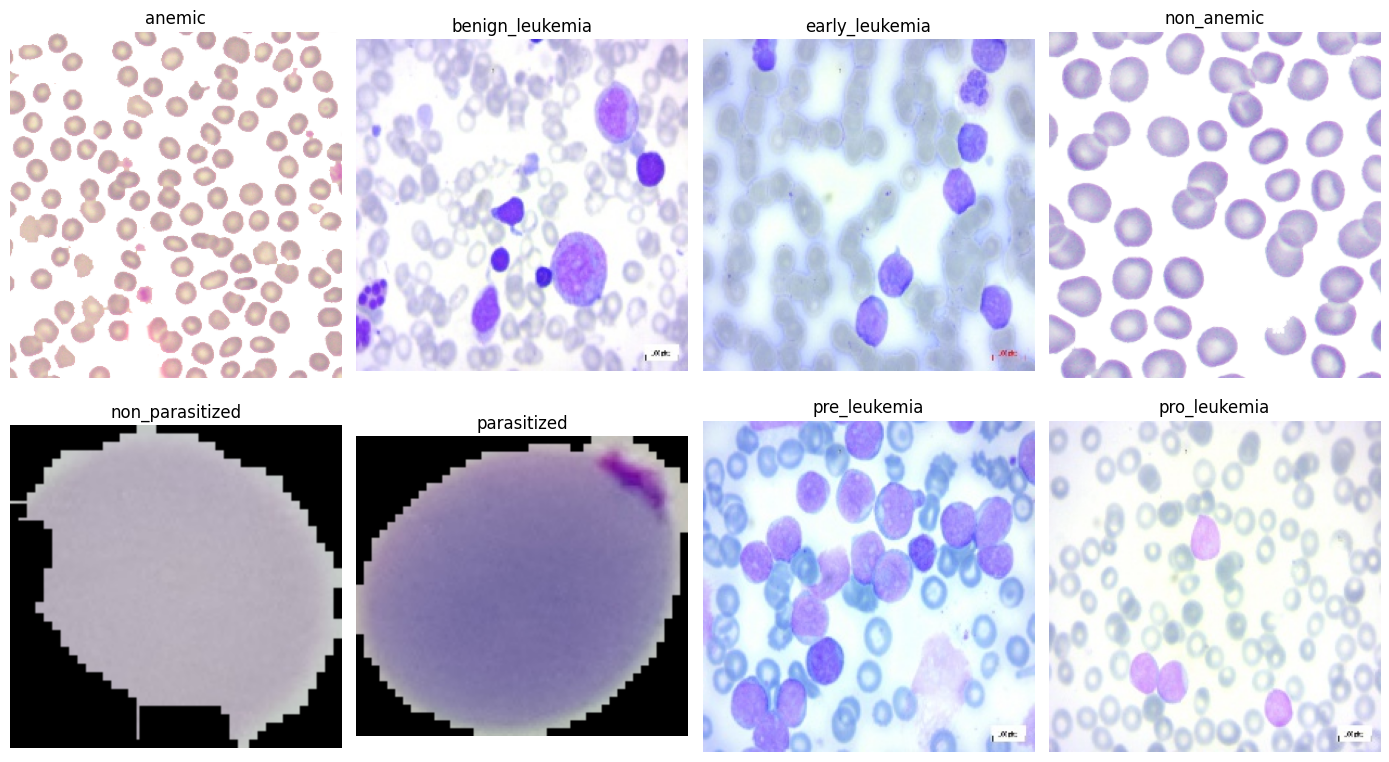

In [10]:
# =========================
# 10. Visual check samples
# =========================

sample_paths = []
for cls in sorted(source_dirs.keys()):
    cls_files = split_df[(split_df['split'] == 'train') & (split_df['class'] == cls)]['path'].tolist()
    if cls_files:
        sample_paths.append(random.choice(cls_files))

plt.figure(figsize=(14, 8))
for i, p in enumerate(sample_paths[:8]):
    img = Image.open(p).convert('RGB')
    cls = Path(p).parent.name
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 7. PyTorch Datasets and DataLoaders

Only the training set uses augmentation. Validation and test sets are kept clean for fair evaluation.

In [11]:
# =========================
# 11. Transforms and dataloaders
# =========================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(DATASET_DIR / 'train', transform=train_transform)
val_dataset = datasets.ImageFolder(DATASET_DIR / 'val', transform=val_test_transform)
test_dataset = datasets.ImageFolder(DATASET_DIR / 'test', transform=val_test_transform)

NUM_CLASSES = len(train_dataset.classes)
print('Classes:', train_dataset.classes)
print('Class to index:', train_dataset.class_to_idx)
print('Train size:', len(train_dataset))
print('Val size:', len(val_dataset))
print('Test size:', len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

class_info = {
    'classes': train_dataset.classes,
    'class_to_idx': train_dataset.class_to_idx,
    'image_size': IMG_SIZE,
    'max_per_class': final_per_class,
    'train_size': len(train_dataset),
    'val_size': len(val_dataset),
    'test_size': len(test_dataset)
}
with open(ARTIFACT_DIR / 'class_info.json', 'w') as f:
    json.dump(class_info, f, indent=4)

Classes: ['anemic', 'benign_leukemia', 'early_leukemia', 'non_anemic', 'non_parasitized', 'parasitized', 'pre_leukemia', 'pro_leukemia']
Class to index: {'anemic': 0, 'benign_leukemia': 1, 'early_leukemia': 2, 'non_anemic': 3, 'non_parasitized': 4, 'parasitized': 5, 'pre_leukemia': 6, 'pro_leukemia': 7}
Train size: 2816
Val size: 600
Test size: 616


## 8. Model Builders

`MultiNet` is implemented here as a **custom lightweight CNN** for your project comparison. The other models are standard CNN architectures.

In [12]:
# =========================
# 12. Model builders
# =========================

import torch
import torch.nn as nn
import torchvision.models as models

class TrueMultiNet(nn.Module):
    def __init__(self, num_classes=8):
        super(TrueMultiNet, self).__init__()
        
        # -----------------------------------------
        # Branch 1: DenseNet201
        # -----------------------------------------
        densenet = models.densenet201(weights=safe_weights(models.DenseNet201_Weights))
        self.densenet_features = densenet.features
        self.densenet_pool = nn.AdaptiveAvgPool2d((1, 1))
        d_out = 1920 # DenseNet201 outputs 1920 feature channels
        
        # -----------------------------------------
        # Branch 2: VGG16
        # -----------------------------------------
        vgg = models.vgg16(weights=safe_weights(models.VGG16_Weights))
        self.vgg_features = vgg.features
        self.vgg_pool = nn.AdaptiveAvgPool2d((1, 1))
        v_out = 512 # VGG16 outputs 512 feature channels
        
        # -----------------------------------------
        # Branch 3: MobileNetV3-Large 
        # (Used as the PyTorch equivalent to NasNetMobile)
        # -----------------------------------------
        mobilenet = models.mobilenet_v3_large(weights=safe_weights(models.MobileNet_V3_Large_Weights))
        self.mobilenet_features = mobilenet.features
        self.mobilenet_pool = nn.AdaptiveAvgPool2d((1, 1))
        m_out = 960 # MobileNetV3-Large outputs 960 feature channels
        
        # -----------------------------------------
        # Fusion & Classification Head
        # -----------------------------------------
        total_features = d_out + v_out + m_out # 1920 + 512 + 960 = 3392
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(total_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract and pool features from each branch
        d_feat = torch.flatten(self.densenet_pool(self.densenet_features(x)), 1)
        v_feat = torch.flatten(self.vgg_pool(self.vgg_features(x)), 1)
        m_feat = torch.flatten(self.mobilenet_pool(self.mobilenet_features(x)), 1)
        
        # Concatenate features along the channel dimension
        fused_features = torch.cat((d_feat, v_feat, m_feat), dim=1)
        
        # Pass through final classifier
        out = self.classifier(fused_features)
        return out


def safe_weights(weight_enum):
    if not USE_PRETRAINED:
        return None
    return weight_enum.DEFAULT


def build_model(model_name, num_classes):
    if model_name == 'multinet':
        model = TrueMultiNet(num_classes)

    elif model_name == 'resnet18':
        model = models.resnet18(weights=safe_weights(ResNet18_Weights))
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == 'mobilenet_v3_small':
        model = models.mobilenet_v3_small(weights=safe_weights(MobileNet_V3_Small_Weights))
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=safe_weights(EfficientNet_B0_Weights))
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == 'vgg16':
        model = models.vgg16(weights=safe_weights(VGG16_Weights))
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == 'densenet121':
        model = models.densenet121(weights=safe_weights(DenseNet121_Weights))
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        
    elif model_name == 'resnet34':
        model = models.resnet34(weights=safe_weights(ResNet34_Weights))
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'resnet50':
        model = models.resnet50(weights=safe_weights(ResNet50_Weights))
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'efficientnet_v2_s':
        model = models.efficientnet_v2_s(weights=safe_weights(EfficientNet_V2_S_Weights))
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        
    elif model_name == 'mobilenet_v3_large':
        model = models.mobilenet_v3_large(weights=safe_weights(MobileNet_V3_Large_Weights))
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        
    elif model_name == 'convnext_tiny':
        model = models.convnext_tiny(weights=safe_weights(ConvNeXt_Tiny_Weights))
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    else:
        raise ValueError(f'Unknown model: {model_name}')

    return model.to(device)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for name in MODELS_TO_RUN:
    m = build_model(name, NUM_CLASSES)
    print(f'{name:20s} trainable parameters: {count_parameters(m):,}')
    del m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

multinet             trainable parameters: 37,520,888
resnet18             trainable parameters: 11,180,616
mobilenet_v3_small   trainable parameters: 1,526,056
efficientnet_b0      trainable parameters: 4,017,796
vgg16                trainable parameters: 134,293,320
densenet121          trainable parameters: 6,962,056
resnet34             trainable parameters: 21,288,776
resnet50             trainable parameters: 23,524,424
efficientnet_v2_s    trainable parameters: 20,187,736
mobilenet_v3_large   trainable parameters: 4,212,280
convnext_tiny        trainable parameters: 27,826,280


## 9. Training and Evaluation Functions

In [13]:
# =========================
# 13. Training and evaluation functions
# =========================

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, total_correct / total


def evaluate_model(model, loader, criterion=None):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            if criterion is not None:
                loss = criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total if criterion is not None else None
    acc = total_correct / total
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)


def train_full_model(model_name):
    print('' + '='*60)
    print('Training:', model_name)
    print('='*60)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    model = build_model(model_name, NUM_CLASSES)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    best_val_acc = 0.0
    best_epoch = 0
    no_improve = 0
    best_path = ARTIFACT_DIR / f'{model_name}_best.pth'

    history = []
    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate_model(model, val_loader, criterion)

        row = {
            'model': model_name,
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
        }
        history.append(row)

        print(f'Epoch {epoch:02d}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            no_improve = 0
            torch.save(model.state_dict(), best_path)
            print('Saved best model:', best_path)
        else:
            no_improve += 1

        if no_improve >= PATIENCE:
            print('Early stopping triggered.')
            break

    train_time = time.time() - start_time

    # Load best model and evaluate on test set
    best_model = build_model(model_name, NUM_CLASSES)
    best_model.load_state_dict(torch.load(best_path, map_location=device))
    best_model = best_model.to(device)

    test_loss, test_acc, y_true, y_pred = evaluate_model(best_model, test_loader, criterion)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    report_text = classification_report(y_true, y_pred, target_names=train_dataset.classes, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    with open(ARTIFACT_DIR / f'{model_name}_classification_report.txt', 'w') as f:
        f.write(report_text)
    np.savetxt(ARTIFACT_DIR / f'{model_name}_confusion_matrix.csv', cm, delimiter=',', fmt='%d')

    pd.DataFrame(history).to_csv(ARTIFACT_DIR / f'{model_name}_history.csv', index=False)

    result = {
        'model': model_name,
        'best_epoch': best_epoch,
        'best_val_acc': best_val_acc,
        'test_acc': test_acc,
        'precision_weighted': precision,
        'recall_weighted': recall,
        'f1_weighted': f1,
        'train_time_sec': train_time,
        'parameters': count_parameters(best_model),
        'model_path': str(best_path),
    }

    print('Test Result:', result)
    print('Classification Report:', report_text)

    del model, best_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

## 10. Run Model Comparison

This cell trains all selected models and creates a comparison table.

If training is slow, reduce `MODELS_TO_RUN`, `EPOCHS`, or `MAX_PER_CLASS` in the settings cell.

In [14]:
# =========================
# 14. Train all models
# =========================

results = []
failed_models = []

for model_name in MODELS_TO_RUN:
    try:
        result = train_full_model(model_name)
        results.append(result)
    except RuntimeError as e:
        print(f'RuntimeError while training {model_name}:', e)
        failed_models.append({'model': model_name, 'error': str(e)})
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception as e:
        print(f'Error while training {model_name}:', e)
        failed_models.append({'model': model_name, 'error': str(e)})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_acc', ascending=False)
results_df.to_csv(ARTIFACT_DIR / 'model_comparison_results.csv', index=False)

print('Model comparison results:')
display(results_df)

if failed_models:
    failed_df = pd.DataFrame(failed_models)
    failed_df.to_csv(ARTIFACT_DIR / 'failed_models.csv', index=False)
    print('Failed models:')
    display(failed_df)

Training: multinet
Epoch 01/20 | Train Acc: 0.5593 | Val Acc: 0.6467 | Val Loss: 0.8145
Saved best model: /kaggle/working/model_artifacts/multinet_best.pth
Epoch 02/20 | Train Acc: 0.7063 | Val Acc: 0.7733 | Val Loss: 0.4800
Saved best model: /kaggle/working/model_artifacts/multinet_best.pth
Epoch 03/20 | Train Acc: 0.7972 | Val Acc: 0.8783 | Val Loss: 0.3441
Saved best model: /kaggle/working/model_artifacts/multinet_best.pth
Epoch 04/20 | Train Acc: 0.8331 | Val Acc: 0.8950 | Val Loss: 0.2660
Saved best model: /kaggle/working/model_artifacts/multinet_best.pth
Epoch 05/20 | Train Acc: 0.8548 | Val Acc: 0.9200 | Val Loss: 0.2136
Saved best model: /kaggle/working/model_artifacts/multinet_best.pth
Epoch 06/20 | Train Acc: 0.8757 | Val Acc: 0.8900 | Val Loss: 0.2818
Epoch 07/20 | Train Acc: 0.8672 | Val Acc: 0.9200 | Val Loss: 0.2448
Epoch 08/20 | Train Acc: 0.8775 | Val Acc: 0.9117 | Val Loss: 0.2017
Early stopping triggered.
Test Result: {'model': 'multinet', 'best_epoch': 5, 'best_val_a

,model,best_epoch,best_val_acc,test_acc,precision_weighted,recall_weighted,f1_weighted,train_time_sec,parameters,model_path
6,resnet34,12,0.911667,0.920455,0.921391,0.920455,0.920345,464.168783,21288776,/kaggle/working/model_artifacts/resnet34_best.pth
5,densenet121,11,0.930000,0.909091,0.909794,0.909091,0.908675,647.665407,6962056,/kaggle/working/model_artifacts/densenet121_be...
0,multinet,5,0.920000,0.904221,0.905830,0.904221,0.903651,944.005286,37520888,/kaggle/working/model_artifacts/multinet_best.pth
9,mobilenet_v3_large,20,0.905000,0.904221,0.906472,0.904221,0.904707,460.972241,4212280,/kaggle/working/model_artifacts/mobilenet_v3_l...
7,resnet50,13,0.898333,0.902597,0.904841,0.902597,0.902210,752.037216,23524424,/kaggle/working/model_artifacts/resnet50_best.pth
3,efficientnet_b0,16,0.901667,0.899351,0.901950,0.899351,0.898584,555.806726,4017796,/kaggle/working/model_artifacts/efficientnet_b...
1,resnet18,8,0.906667,0.889610,0.892828,0.889610,0.888481,262.070019,11180616,/kaggle/working/model_artifacts/resnet18_best.pth
8,efficientnet_v2_s,11,0.888333,0.871753,0.872362,0.871753,0.871668,719.947958,20187736,/kaggle/working/model_artifacts/efficientnet_v...
2,mobilenet_v3_small,12,0.845000,0.860390,0.899213,0.860390,0.848242,302.232395,1526056,/kaggle/working/model_artifacts/mobilenet_v3_s...
4,vgg16,12,0.863333,0.847403,0.853625,0.847403,0.847059,996.627351,134293320,/kaggle/working/model_artifacts/vgg16_best.pth


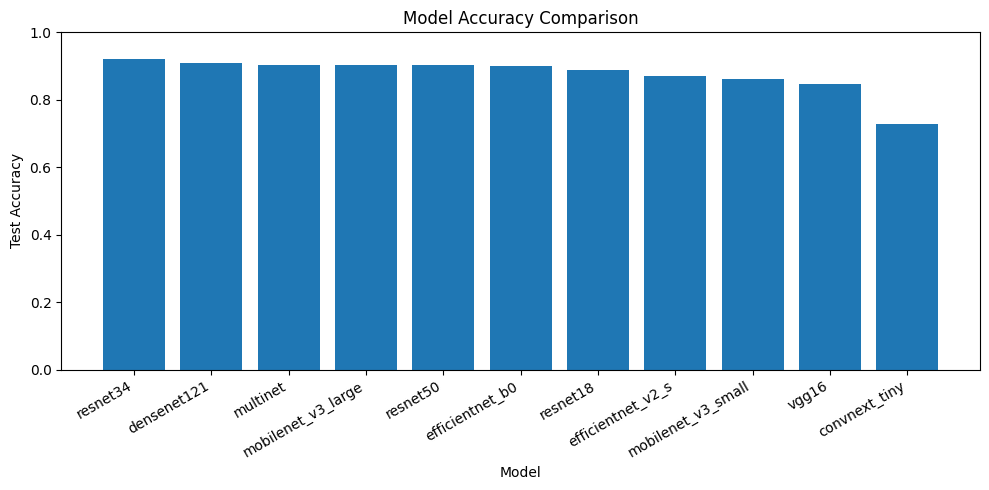

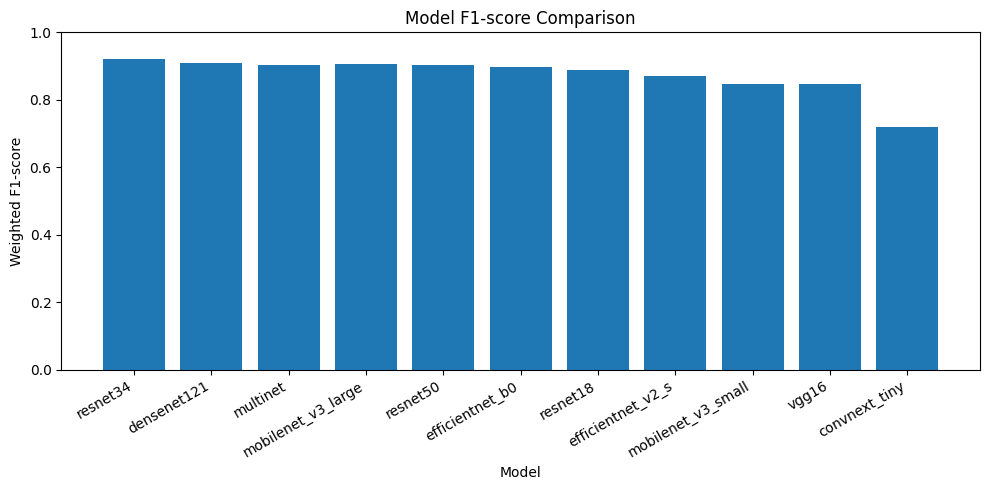

In [15]:
# =========================
# 15. Plot model comparison
# =========================

if len(results_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(results_df['model'], results_df['test_acc'])
    plt.ylabel('Test Accuracy')
    plt.xlabel('Model')
    plt.title('Model Accuracy Comparison')
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'model_accuracy_comparison.png', dpi=200)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(results_df['model'], results_df['f1_weighted'])
    plt.ylabel('Weighted F1-score')
    plt.xlabel('Model')
    plt.title('Model F1-score Comparison')
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'model_f1_comparison.png', dpi=200)
    plt.show()

## 11. Detailed Evaluation of the Best Model

Best model: resnet34
Best model path: /kaggle/working/model_artifacts/resnet34_best.pth
Best Model Test Accuracy: 0.9204545454545454
                 precision    recall  f1-score   support

         anemic       0.77      0.71      0.74        77
benign_leukemia       1.00      0.97      0.99        77
 early_leukemia       0.97      1.00      0.99        77
     non_anemic       0.73      0.79      0.76        77
non_parasitized       0.91      0.97      0.94        77
    parasitized       0.97      0.91      0.94        77
   pre_leukemia       1.00      1.00      1.00        77
   pro_leukemia       1.00      1.00      1.00        77

       accuracy                           0.92       616
      macro avg       0.92      0.92      0.92       616
   weighted avg       0.92      0.92      0.92       616



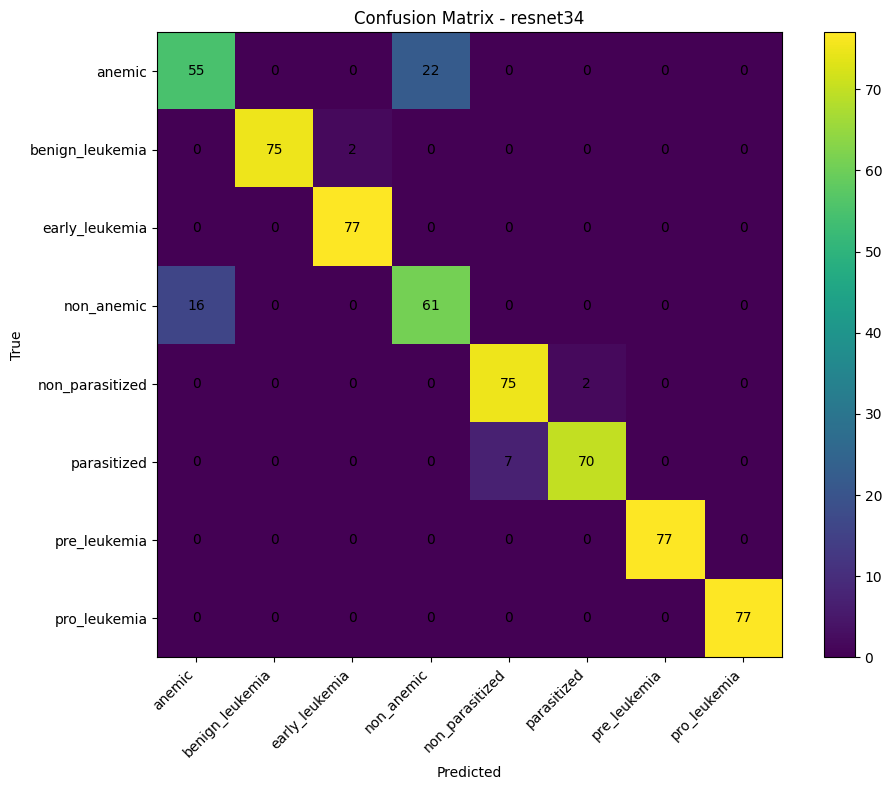

In [16]:
# =========================
# 16. Best model detailed evaluation
# =========================

if len(results_df) == 0:
    raise RuntimeError('No successful model result found.')

best_row = results_df.iloc[0]
best_model_name = best_row['model']
best_model_path = best_row['model_path']

print('Best model:', best_model_name)
print('Best model path:', best_model_path)

best_model = build_model(best_model_name, NUM_CLASSES)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model = best_model.to(device)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate_model(best_model, test_loader, criterion)

print('Best Model Test Accuracy:', test_acc)
print(classification_report(y_true, y_pred, target_names=train_dataset.classes, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.colorbar()

classes = train_dataset.classes
ticks = np.arange(len(classes))
plt.xticks(ticks, classes, rotation=45, ha='right')
plt.yticks(ticks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / f'{best_model_name}_confusion_matrix.png', dpi=200)
plt.show()

## 12. Save Everything for Download

The following cell creates a ZIP file containing:

- Best model weights for each architecture
- Model comparison table
- Class information
- Confusion matrices
- Training histories
- Leakage check manifests

In [17]:
# =========================
# 17. Save final artifacts as ZIP
# =========================

summary = {
    'project': 'Combined 8-Class Blood Disease Classification',
    'classes': train_dataset.classes,
    'class_to_idx': train_dataset.class_to_idx,
    'max_per_class': final_per_class,
    'image_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'use_pretrained': USE_PRETRAINED,
    'models_run': MODELS_TO_RUN,
    'best_model': best_model_name,
    'best_test_accuracy': float(test_acc),
    'leakage_check': 'No duplicate MD5 hash across train/val/test splits',
}

with open(ARTIFACT_DIR / 'experiment_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

zip_path = shutil.make_archive(str(WORKING_DIR / 'capstone_combined_model_comparison_artifacts'), 'zip', ARTIFACT_DIR)
print('Artifacts saved to:', zip_path)
print('You can download it from Kaggle Output panel.')

Artifacts saved to: /kaggle/working/capstone_combined_model_comparison_artifacts.zip
You can download it from Kaggle Output panel.


In [18]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 97.8 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=29bb9c9f5dbacc30a03ee256cb0de73715319a68fc2a92cab3c71045380bccdb
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Generating Grad-CAM visualizations for all 8 classes using vgg16...


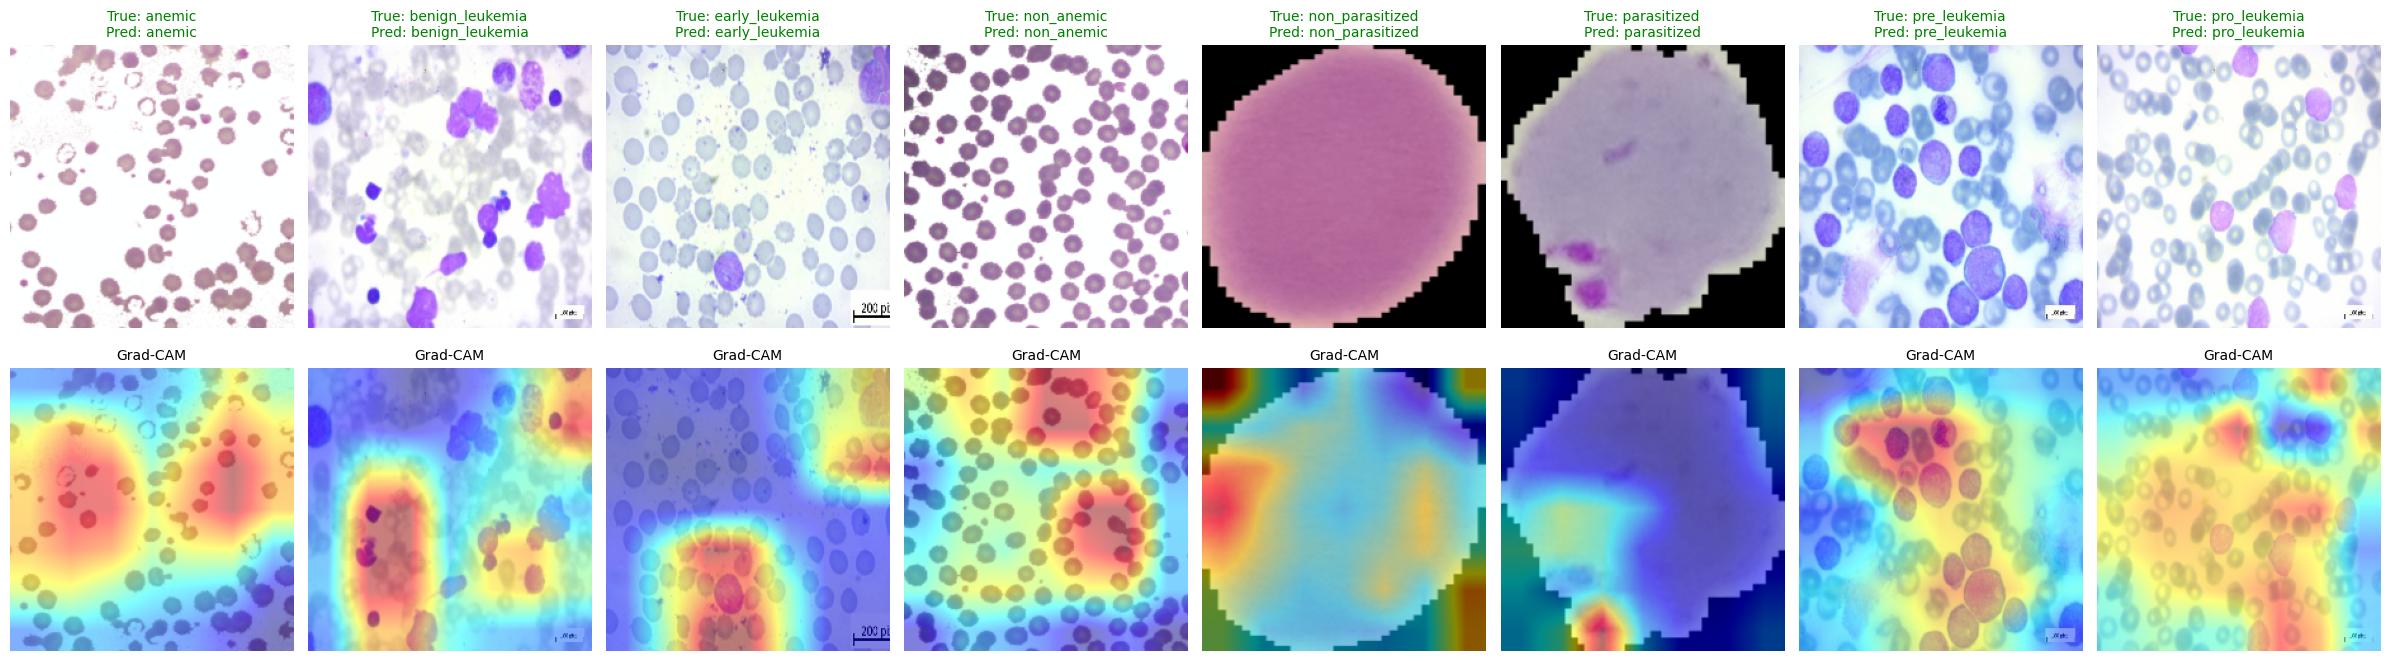

In [19]:
# =========================
# 18. XAI: Grad-CAM Visualization (All Classes)
# =========================
import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("Generating Grad-CAM visualizations for all 8 classes using vgg16...")

# 1. Load the best DenseNet121 model
best_model_name = 'vgg16'
best_model_path = ARTIFACT_DIR / f'{best_model_name}_best.pth'

cam_model = build_model(best_model_name, NUM_CLASSES)
cam_model.load_state_dict(torch.load(best_model_path, map_location=device))
cam_model = cam_model.to(device)
cam_model.eval()

# 2. Define the target layer for DenseNet121
target_layers = [cam_model.features[-1]]

# 3. Initialize Grad-CAM
cam = GradCAM(model=cam_model, target_layers=target_layers)

# 4. Explicitly collect exactly one image per class from the test dataset
class_samples = {}
for img, label in test_dataset:
    if label not in class_samples:
        class_samples[label] = img
    # Stop searching once we have one image for all 8 classes
    if len(class_samples) == NUM_CLASSES:
        break

# Sort them by label index (0 to 7) so they appear in consistent order
sorted_labels = sorted(class_samples.keys())
images_list = [class_samples[lbl] for lbl in sorted_labels]

# Stack the list of 3D tensors into a single 4D batch tensor
images = torch.stack(images_list).to(device)

# 5. Plot Original vs Grad-CAM for all 8 classes
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(24, 7))

for i in range(NUM_CLASSES):
    input_tensor = images[i].unsqueeze(0)
    true_label = sorted_labels[i]
    true_class_name = train_dataset.classes[true_label]
    
    # Get model prediction
    with torch.no_grad():
        outputs = cam_model(input_tensor)
        pred_label = torch.argmax(outputs, dim=1).item()
        pred_class_name = train_dataset.classes[pred_label]
    
    # Generate CAM for the predicted class
    targets = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Un-normalize the image tensor for plotting
    img_np = images[i].cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1) # Ensure valid pixel range
    
    # Overlay heatmap
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    
    # Top Row: Original Image
    axes[0, i].imshow(img_np)
    # Highlight title in red if prediction is wrong, green if correct
    color = "green" if true_label == pred_label else "red"
    axes[0, i].set_title(f"True: {true_class_name}\nPred: {pred_class_name}", color=color, fontsize=10)
    axes[0, i].axis('off')
    
    # Bottom Row: Grad-CAM Heatmap
    axes[1, i].imshow(visualization)
    axes[1, i].set_title("Grad-CAM", fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / f'{best_model_name}_gradcam_all_classes.png', dpi=200)
plt.show()

# Free memory
del cam_model, cam
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [20]:
# =========================
# 18. YOLO11 Setup and Installation
# =========================
# Install the ultralytics package to access YOLO11 models
!pip install -q ultralytics

from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import torch

# Explicitly define variables in case the session restarted
WORKING_DIR = Path('/kaggle/working')
DATASET_DIR = WORKING_DIR / 'combined_8class_dataset'
ARTIFACT_DIR = WORKING_DIR / 'model_artifacts'
EPOCHS = 20        # Match your previous setup
IMG_SIZE = 224     # Match your previous setup
BATCH_SIZE = 16    # Match your previous setup

# Define the YOLO11 classification models to compare
yolo_models = [
    'yolo11n-cls.pt', # Nano
    'yolo11s-cls.pt', # Small
    'yolo11m-cls.pt', # Medium
    'yolo11l-cls.pt', # Large
    'yolo11x-cls.pt'  # Extra Large
]

# Directory to save YOLO training runs
YOLO_RUNS_DIR = WORKING_DIR / 'yolo_runs'
YOLO_RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("YOLO11 models to train:", yolo_models)
print("Data directory being used:", DATASET_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO11 models to train: ['yolo11n-cls.pt', 'yolo11s-cls.pt', 'yolo11m-cls.pt', 'yolo11l-cls.pt', 'yolo11x-cls.pt']
Data directory being used: /kaggle/working/combined_8class_dataset


In [21]:
# =========================
# 19. Train YOLO11 Models
# =========================
yolo_training_results = {}

for yolo_model_name in yolo_models:
    print(f"\n{'='*50}")
    print(f"Training {yolo_model_name}...")
    print(f"{'='*50}")
    
    # Clean the run name by removing the file extension
    run_name = yolo_model_name.replace('.pt', '')
    
    # Initialize the model
    model = YOLO(yolo_model_name)
    
    # Train the model
    # Note: Ultralytics handles its own data loading and augmentations
    results = model.train(
        data=str(DATASET_DIR),
        epochs=EPOCHS, 
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        project=str(YOLO_RUNS_DIR),
        name=run_name,
        device=0 if torch.cuda.is_available() else 'cpu',
        verbose=False # Set to True if you want detailed batch-by-batch logs
    )
    
    yolo_training_results[yolo_model_name] = results
    
    # Free memory after each model
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nAll YOLO models finished training!")


Training yolo11n-cls.pt...
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/combined_8class_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n-cls, nbs=64, nms=False, opset=None, optimize=False, opt

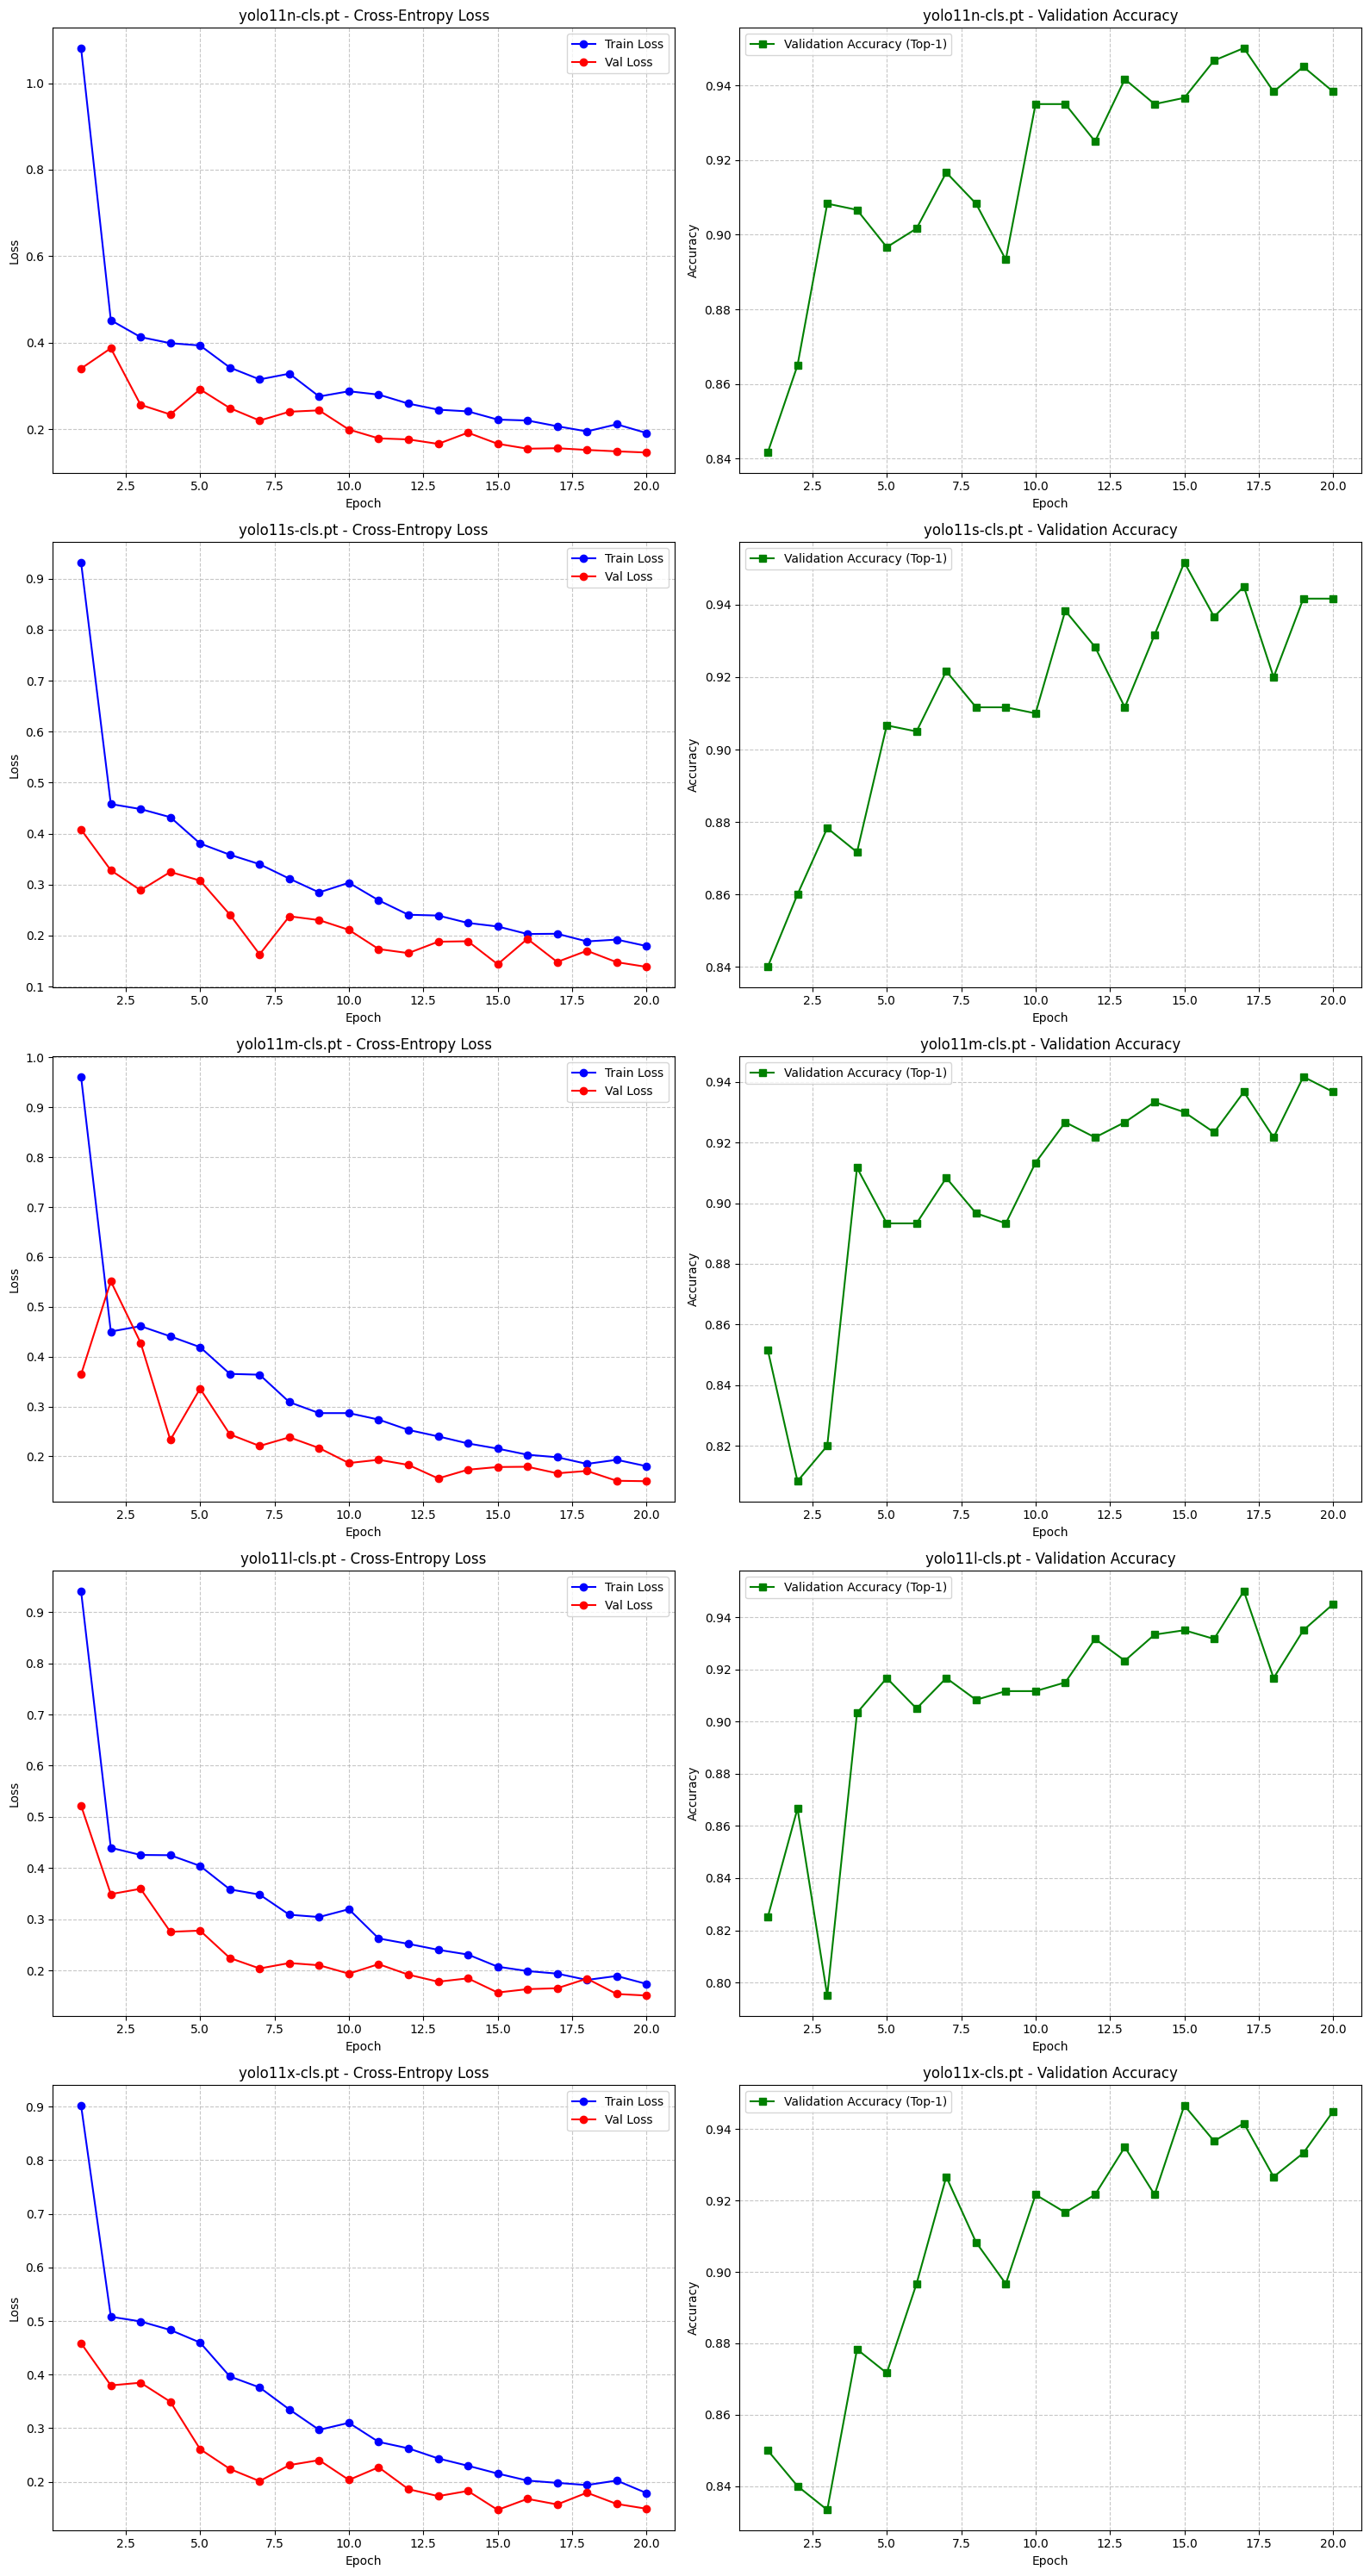

In [22]:
# =========================
# 20. Visualize YOLO11 Training/Validation Graphs
# =========================
# Create a figure with a grid of subplots (1 row per model, 2 columns for Loss and Accuracy)
fig, axes = plt.subplots(len(yolo_models), 2, figsize=(16, 6 * len(yolo_models)))

for i, yolo_model_name in enumerate(yolo_models):
    run_name = yolo_model_name.replace('.pt', '')
    csv_path = YOLO_RUNS_DIR / run_name / 'results.csv'
    
    if csv_path.exists():
        # Read the training log
        df = pd.read_csv(csv_path)
        
        # Clean up column names (Ultralytics often adds leading/trailing spaces)
        df.columns = [col.strip() for col in df.columns]
        
        # Plot 1: Train & Val Loss
        axes[i, 0].plot(df['epoch'], df['train/loss'], label='Train Loss', marker='o', color='blue')
        axes[i, 0].plot(df['epoch'], df['val/loss'], label='Val Loss', marker='o', color='red')
        axes[i, 0].set_title(f'{yolo_model_name} - Cross-Entropy Loss')
        axes[i, 0].set_xlabel('Epoch')
        axes[i, 0].set_ylabel('Loss')
        axes[i, 0].grid(True, linestyle='--', alpha=0.7)
        axes[i, 0].legend()
        
        # Plot 2: Top-1 Accuracy
        # Identify the correct accuracy column dynamically
        acc_cols = [c for c in df.columns if 'accuracy_top1' in c or 'acc' in c]
        if len(acc_cols) > 0:
            top1_acc_col = acc_cols[0]
            axes[i, 1].plot(df['epoch'], df[top1_acc_col], label='Validation Accuracy (Top-1)', marker='s', color='green')
            axes[i, 1].set_title(f'{yolo_model_name} - Validation Accuracy')
            axes[i, 1].set_xlabel('Epoch')
            axes[i, 1].set_ylabel('Accuracy')
            axes[i, 1].grid(True, linestyle='--', alpha=0.7)
            axes[i, 1].legend()
        else:
            axes[i, 1].text(0.5, 0.5, 'Accuracy metric not found', ha='center', va='center')
            
    else:
        print(f"Results not found for {yolo_model_name} at {csv_path}")

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'yolo_training_curves.png', dpi=200)
plt.show()

In [26]:
# =========================
# 22. YOLO Models Comparison Table
# =========================
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from pathlib import Path
import os
from ultralytics import YOLO

print("Evaluating YOLO models on the test set to build the comparison table...")

yolo_results = []

# Prepare test set paths and true labels
test_dir = DATASET_DIR / 'test'
class_names = sorted([d.name for d in test_dir.iterdir() if d.is_dir()])
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

test_image_paths = []
y_true = []

for cls_name in class_names:
    cls_dir = test_dir / cls_name
    for img_path in cls_dir.glob('*.*'):
        # Keep only standard image formats
        if img_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}:
            test_image_paths.append(str(img_path))
            y_true.append(class_to_idx[cls_name])

# Iterate over each YOLO model to extract metrics and evaluate
for yolo_model_name in yolo_models:
    run_name = yolo_model_name.replace('.pt', '')
    best_weights_path = YOLO_RUNS_DIR / run_name / 'weights' / 'best.pt'
    csv_path = YOLO_RUNS_DIR / run_name / 'results.csv'
    
    if not best_weights_path.exists() or not csv_path.exists():
        print(f"Skipping {yolo_model_name}: files not found.")
        continue
        
    # 1. Get best validation accuracy and epoch from the training logs
    df = pd.read_csv(csv_path)
    df.columns = [col.strip() for col in df.columns] # Clean column headers
    
    acc_cols = [c for c in df.columns if 'accuracy_top1' in c or 'acc' in c]
    if acc_cols:
        best_val_acc = df[acc_cols[0]].max()
        # Find the epoch where this max accuracy occurred
        best_epoch = df[df[acc_cols[0]] == best_val_acc]['epoch'].iloc[0]
    else:
        best_val_acc = 0.0
        best_epoch = 0

    # 2. Load the best model weights
    model = YOLO(best_weights_path)
    
    # 3. Calculate trainable parameters
    # Ultralytics models are nested in a PyTorch module
    params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
    
    # 4. Run inference on the test set
    # Using batch prediction for memory efficiency and speed
    results = model.predict(source=test_image_paths, batch=BATCH_SIZE, imgsz=IMG_SIZE, verbose=False)
    
    # 5. Extract predicted class indices
    y_pred = [r.probs.top1 for r in results]
    
    # 6. Calculate SciKit-Learn metrics to match your previous CNN table
    test_acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    # Compile the row data
    yolo_results.append({
        'model': f"yolo_{run_name}",
        'best_epoch': best_epoch,
        'best_val_acc': best_val_acc,
        'test_acc': test_acc,
        'precision_weighted': precision,
        'recall_weighted': recall,
        'f1_weighted': f1,
        'parameters': params,
        'model_path': str(best_weights_path)
    })
    
    # Free up memory before loading the next model
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Build and save the DataFrame
yolo_results_df = pd.DataFrame(yolo_results)
if not yolo_results_df.empty:
    yolo_results_df = yolo_results_df.sort_values('test_acc', ascending=False).reset_index(drop=True)
    yolo_results_df.to_csv(ARTIFACT_DIR / 'yolo_model_comparison_results.csv', index=False)
    
    print("\n✅ YOLO Model Comparison Results:")
    display(yolo_results_df)
else:
    print("\n❌ No YOLO results could be compiled.")

Evaluating YOLO models on the test set to build the comparison table...

✅ YOLO Model Comparison Results:


,model,best_epoch,best_val_acc,test_acc,precision_weighted,recall_weighted,f1_weighted,parameters,model_path
0,yolo_yolo11s-cls,15,0.95167,0.944805,0.946114,0.944805,0.944674,0,/kaggle/working/yolo_runs/yolo11s-cls/weights/...
1,yolo_yolo11m-cls,19,0.94167,0.938312,0.939023,0.938312,0.938360,0,/kaggle/working/yolo_runs/yolo11m-cls/weights/...
2,yolo_yolo11l-cls,17,0.95000,0.935065,0.936621,0.935065,0.934836,0,/kaggle/working/yolo_runs/yolo11l-cls/weights/...
3,yolo_yolo11x-cls,15,0.94667,0.933442,0.938167,0.933442,0.932756,0,/kaggle/working/yolo_runs/yolo11x-cls/weights/...
4,yolo_yolo11n-cls,17,0.95000,0.930195,0.930492,0.930195,0.930169,0,/kaggle/working/yolo_runs/yolo11n-cls/weights/...


Best YOLO Model Found: yolo11s-cls (Top-1 Accuracy: 0.9517)


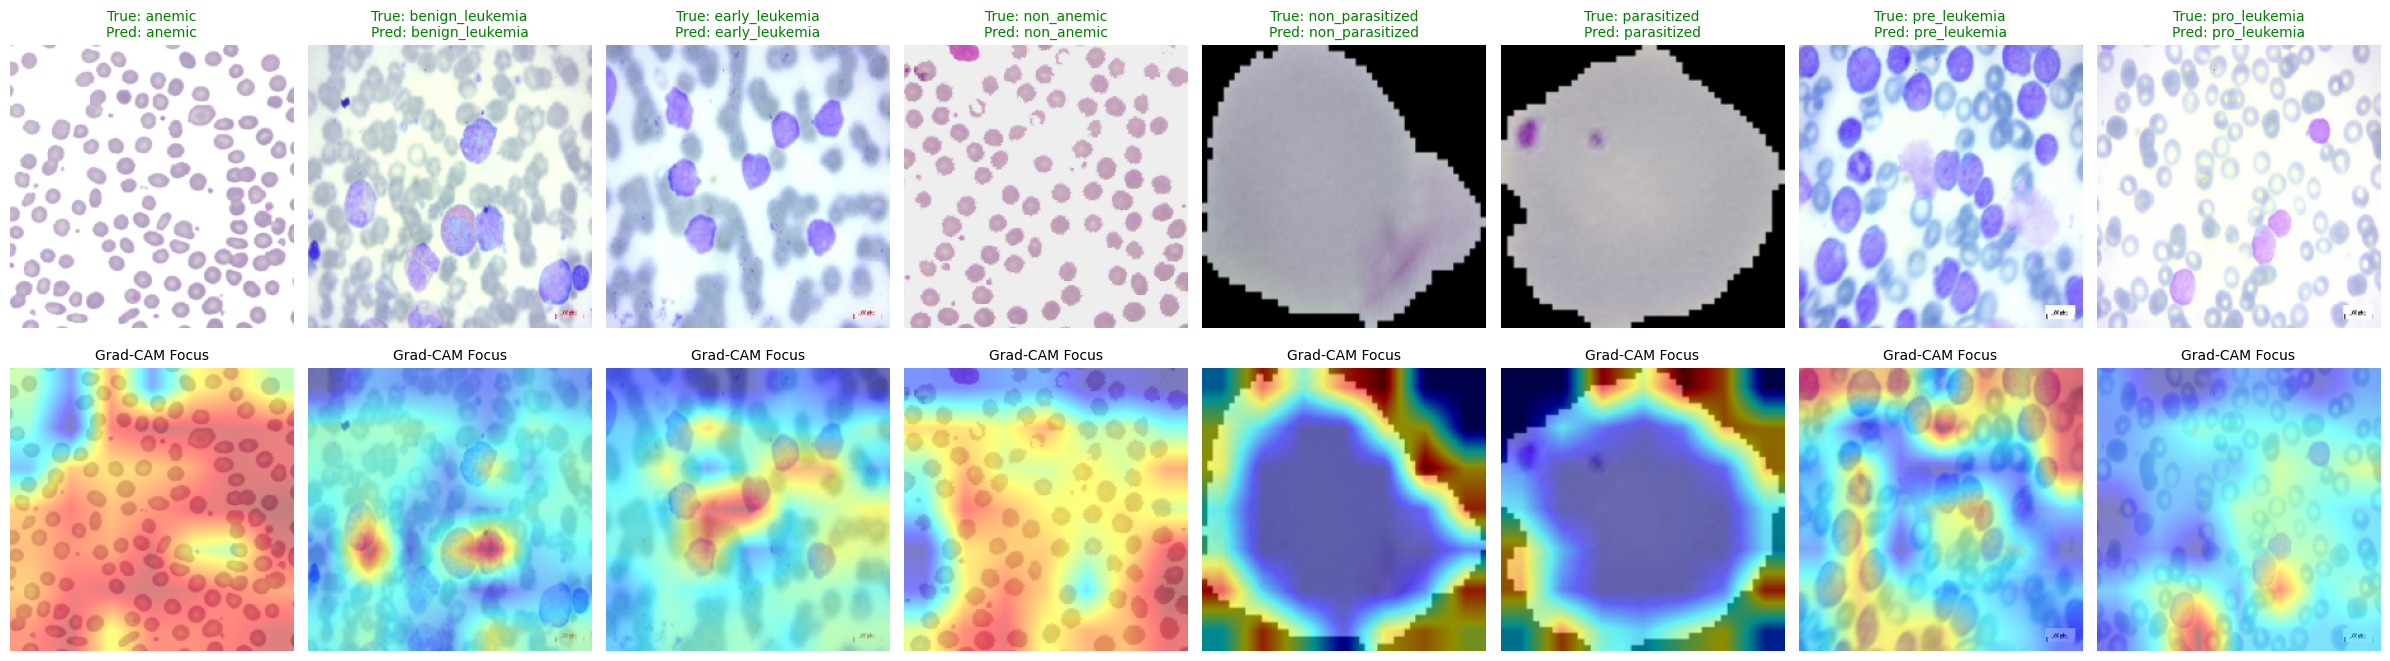

In [25]:
# =========================
# 21. Explainable AI (XAI) for the Best YOLO11 Model
# =========================
import cv2
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
from ultralytics import YOLO

# Import Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# -----------------------------------------
# Step 1: Find the best YOLO model dynamically
# -----------------------------------------
best_acc = 0.0
best_yolo_run = None

for yolo_model_name in yolo_models:
    run_name = yolo_model_name.replace('.pt', '')
    csv_path = YOLO_RUNS_DIR / run_name / 'results.csv'
    
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = [col.strip() for col in df.columns] # Clean headers
        
        acc_cols = [c for c in df.columns if 'accuracy_top1' in c or 'acc' in c]
        if acc_cols:
            max_acc = df[acc_cols[0]].max()
            if max_acc > best_acc:
                best_acc = max_acc
                best_yolo_run = run_name

print(f"Best YOLO Model Found: {best_yolo_run} (Top-1 Accuracy: {best_acc:.4f})")
best_weights_path = YOLO_RUNS_DIR / best_yolo_run / 'weights' / 'best.pt'

# -----------------------------------------
# Step 2: Load and Wrap the YOLO Model
# -----------------------------------------
# Load the raw Ultralytics PyTorch model
yolo_full = YOLO(best_weights_path)
yolo_pytorch_model = yolo_full.model.eval().to(device)

# FIX: Force the model parameters to allow gradients (needed for Grad-CAM)
for param in yolo_pytorch_model.parameters():
    param.requires_grad = True

class YOLOClsWrapper(nn.Module):
    """
    Wraps the YOLO classification model so it returns raw logits.
    Grad-CAM needs logits to compute gradients correctly.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, x):
        out = self.model(x)
        # Ultralytics in eval mode returns (probabilities, logits)
        if isinstance(out, (list, tuple)) and len(out) == 2:
            return out[1] 
        return out

wrapped_model = YOLOClsWrapper(yolo_pytorch_model)

# Target the last feature extraction block before the classification head
# In YOLO11, model.model[-2] is the last spatial bottleneck
target_layers = [yolo_pytorch_model.model[-2]]

cam = GradCAM(model=wrapped_model, target_layers=target_layers)

# -----------------------------------------
# Step 3: Run Inference and Generate Grad-CAM
# -----------------------------------------
test_dir = DATASET_DIR / 'test'
class_names = sorted(os.listdir(test_dir))
NUM_CLASSES = len(class_names)

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(24, 7))

for i, cls_name in enumerate(class_names):
    # Grab the first image in each test class directory
    img_name = os.listdir(test_dir / cls_name)[0]
    img_path = test_dir / cls_name / img_name
    
    # Read and preprocess the image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_float = np.float32(img_resized) / 255.0
    
    # Convert to tensor: shape [1, 3, 224, 224]
    input_tensor = torch.from_numpy(img_float).permute(2, 0, 1).unsqueeze(0).to(device)
    
    # FIX: Tell PyTorch to build a computational graph for this image
    input_tensor.requires_grad_(True)
    
    # 1. Get Model Prediction (Using no_grad only for getting the string label)
    with torch.no_grad():
        preds = wrapped_model(input_tensor)
        pred_idx = preds.argmax(dim=1).item()
        pred_class_name = yolo_full.names[pred_idx]
    
    # 2. Generate Grad-CAM Heatmap (This needs gradients!)
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Overlay heatmap on original image
    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)
    
    # 3. Plot Original Image (Top Row)
    color = "green" if cls_name == pred_class_name else "red"
    axes[0, i].imshow(img_float)
    axes[0, i].set_title(f"True: {cls_name}\nPred: {pred_class_name}", color=color, fontsize=10)
    axes[0, i].axis('off')
    
    # 4. Plot Grad-CAM (Bottom Row)
    axes[1, i].imshow(visualization)
    axes[1, i].set_title("Grad-CAM Focus", fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / f'yolo_{best_yolo_run}_gradcam.png', dpi=200)
plt.show()

# Free up memory
del wrapped_model, yolo_full, yolo_pytorch_model, cam
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Running Ensemble on: cuda
Evaluating 616 test images...


100%|██████████| 616/616 [00:11<00:00, 51.60it/s]



ENSEMBLE PERFORMANCE
Test Accuracy: 0.9399
F1-Score:      0.9399

Classification Report:
                  precision    recall  f1-score   support

         anemic       0.82      0.79      0.81        77
benign_leukemia       1.00      1.00      1.00        77
 early_leukemia       1.00      1.00      1.00        77
     non_anemic       0.80      0.83      0.82        77
non_parasitized       0.93      0.97      0.95        77
    parasitized       0.97      0.92      0.95        77
   pre_leukemia       1.00      1.00      1.00        77
   pro_leukemia       1.00      1.00      1.00        77

       accuracy                           0.94       616
      macro avg       0.94      0.94      0.94       616
   weighted avg       0.94      0.94      0.94       616



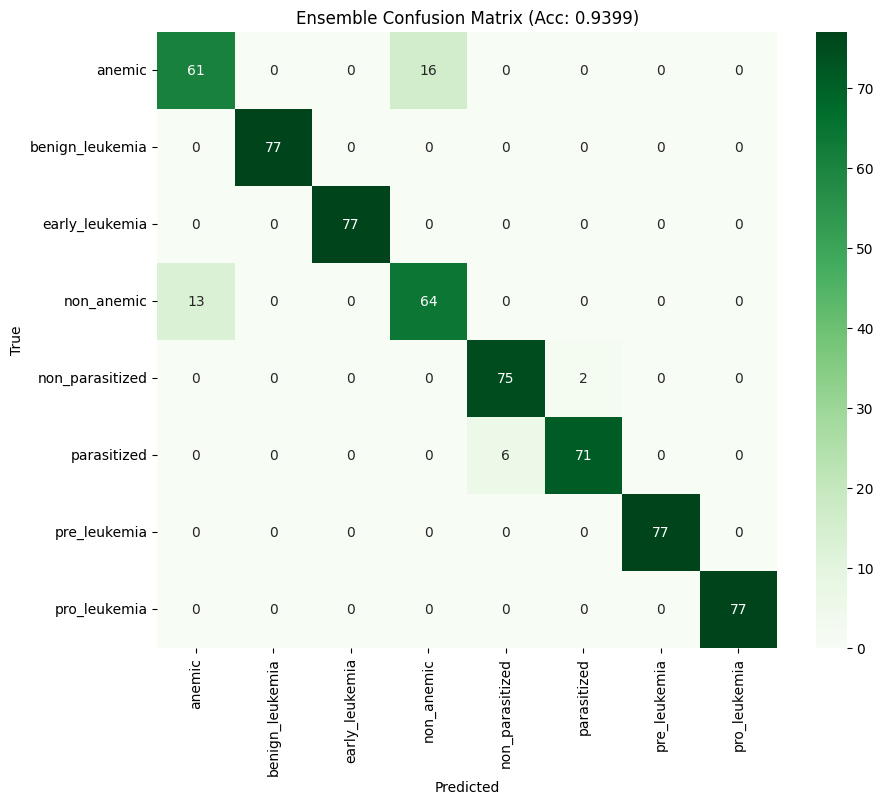

,model,best_epoch,best_val_acc,test_acc,precision_weighted,recall_weighted,f1_weighted,parameters,model_path
0,yolo_yolo11s-cls,15,0.95167,0.944805,0.946114,0.944805,0.944674,0,/kaggle/working/yolo_runs/yolo11s-cls/weights/...
1,Ensemble_YOLO11s_ResNet34_TTA,N/A,N/A,0.939935,NaN,NaN,0.939908,26733152,NaN
2,yolo_yolo11m-cls,19,0.94167,0.938312,0.939023,0.938312,0.938360,0,/kaggle/working/yolo_runs/yolo11m-cls/weights/...
3,yolo_yolo11l-cls,17,0.95,0.935065,0.936621,0.935065,0.934836,0,/kaggle/working/yolo_runs/yolo11l-cls/weights/...
4,yolo_yolo11x-cls,15,0.94667,0.933442,0.938167,0.933442,0.932756,0,/kaggle/working/yolo_runs/yolo11x-cls/weights/...
5,yolo_yolo11n-cls,17,0.95,0.930195,0.930492,0.930195,0.930169,0,/kaggle/working/yolo_runs/yolo11n-cls/weights/...


In [28]:
# ============================================================
# 23. Hybrid Ensemble with Manual TTA & Proper Table Handling
# ============================================================
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from torchvision import transforms, models
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

# 1. Setup & Load Models
# -----------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running Ensemble on: {device}")

# Load ResNet34 (Best CNN)
resnet_path = ARTIFACT_DIR / 'resnet34_best.pth'
resnet_model = models.resnet34(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, NUM_CLASSES)
resnet_model.load_state_dict(torch.load(resnet_path, map_location=device))
resnet_model.to(device).eval()

# Load YOLO11s (Best YOLO)
yolo_path = YOLO_RUNS_DIR / 'yolo11s-cls' / 'weights' / 'best.pt'
yolo_model = YOLO(yolo_path)

# 2. Updated Inference Logic (Manual TTA for both)
# -----------------------------------------------
resnet_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_ensemble_prediction_with_tta(img_path, weight_yolo=0.5, weight_resnet=0.5):
    """
    Predicts using Ensemble + Manual TTA (Original + Horizontal Flip).
    """
    img_pil = Image.open(img_path).convert('RGB')
    img_flipped = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
    
    # --- ResNet Inference ---
    tensors = torch.stack([resnet_transform(img_pil), resnet_transform(img_flipped)]).to(device)
    with torch.no_grad():
        logits = resnet_model(tensors)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        resnet_final_probs = np.mean(probs, axis=0) # Average
    
    # --- YOLO Inference (Manual TTA) ---
    # We pass both images as a list to YOLO
    yolo_res = yolo_model.predict([img_pil, img_flipped], verbose=False)
    yolo_probs_1 = yolo_res[0].probs.data.cpu().numpy()
    yolo_probs_2 = yolo_res[1].probs.data.cpu().numpy()
    yolo_final_probs = (yolo_probs_1 + yolo_probs_2) / 2 # Average
    
    # --- Combine Scores ---
    combined_probs = (weight_yolo * yolo_final_probs) + (weight_resnet * resnet_final_probs)
    return np.argmax(combined_probs)

# 3. Comprehensive Evaluation
# ---------------------------
test_dir = DATASET_DIR / 'test'
test_files = []
for cls_idx, cls_name in enumerate(train_dataset.classes):
    for img_p in (test_dir / cls_name).glob('*.*'):
        test_files.append((str(img_p), cls_idx))

y_true, y_pred = [], []
print(f"Evaluating {len(test_files)} test images...")

for img_p, true_label in tqdm(test_files):
    y_pred.append(get_ensemble_prediction_with_tta(img_p))
    y_true.append(true_label)

# 4. Metrics & Visualization
# ---------------------------
test_acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print(f"\n{'='*30}\nENSEMBLE PERFORMANCE\n{'='*30}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"F1-Score:      {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=train_dataset.classes))

# 5. Update Comparison Table Safely
# ---------------------------------
ensemble_name = 'Ensemble_YOLO11s_ResNet34_TTA'
ensemble_row = {
    'model': ensemble_name,
    'test_acc': test_acc,
    'f1_weighted': f1,
    'parameters': sum(p.numel() for p in resnet_model.parameters()) + 5444376,
    'best_epoch': 'N/A', 'best_val_acc': 'N/A'
}

# Remove existing ensemble row if it exists to avoid duplicates
if ensemble_name in yolo_results_df['model'].values:
    yolo_results_df = yolo_results_df[yolo_results_df['model'] != ensemble_name]

yolo_results_df = pd.concat([yolo_results_df, pd.DataFrame([ensemble_row])], ignore_index=True)
yolo_results_df = yolo_results_df.sort_values('test_acc', ascending=False).reset_index(drop=True)

# Final Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.title(f"Ensemble Confusion Matrix (Acc: {test_acc:.4f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

display(yolo_results_df)